# Model-condition sweep: FN error & runtime

Each simulation perturbs **one** parameter of the *default* config
(`poly=high, homoplasy=0.1, tree_height=4, n_chars=320`) while holding the rest fixed.
For every swept parameter we plot **FN error rate** (RF false negatives, normalised)
by method, and finally **runtime** vs number of characters.

**Scope: plain trees only** — restricted to `horizontal_edges == 0`. The registry
sweeps reticulation 0–3; reticulation robustness is out of scope here.

Data = `inference_registry.csv` ⨝ `simulated_data_registry.csv` (on `dataset_id`==`path`)
⨝ `scores.csv` (on `dataset_id, method, config_hash`). Run `pch experiment score` first
so `scores.csv` exists.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Repo root = nearest ancestor holding `experiments/` (works whether the kernel
# starts in scripts/pynb/ or the repo root).
REPO = Path.cwd()
while not (REPO / "experiments").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
EXP = REPO / "experiments" / "sample_experiment"
FIGS = REPO / "scripts" / "pynb" / "figures"
FIGS.mkdir(exist_ok=True)
print("experiment:", EXP)

experiment: /projects/illinois/eng/cs/warnow/zxliu2/PCH-ASTRAL/experiments/sample_experiment


In [2]:
inf = pd.read_csv(EXP / "inference_data" / "inference_registry.csv")
sim = pd.read_csv(EXP / "simulation_data" / "simulated_data_registry.csv")
scores = pd.read_csv(EXP / "inference_data" / "scores.csv")

# The sim registry double-lists the default (high_0.1_4_320) datasets as exact
# duplicate rows, and that duplication propagated into scores.csv too. Drop the
# dupes on both so the joins don't double-count that condition.
sim = sim.drop_duplicates(subset="path")
scores = scores.drop_duplicates(subset=["dataset_id", "method", "config_hash"])

df = (inf.merge(sim, left_on="dataset_id", right_on="path")
         .merge(scores, on=["dataset_id", "method", "config_hash"]))

# Restrict to plain trees (no reticulation). horizontal_edges sweeps 0..3 in the
# registry; this analysis is tree-only, so hold it at 0 explicitly rather than
# silently averaging over reticulate networks.
df = df[df["horizontal_edges"] == 0].reset_index(drop=True)

df["FN error rate (%)"] = df["fn_rate"] * 100
print(f"{len(df)} scored (dataset, method) rows at horizontal_edges==0")
df[["poly_level", "homoplasy_factor", "min_tree_height",
    "character_count", "method", "fn_rate", "runtime_seconds"]].head()

1408 scored (dataset, method) rows at horizontal_edges==0


,poly_level,homoplasy_factor,min_tree_height,character_count,method,fn_rate,runtime_seconds
0,high,0.1,4,320,mp,0.074074,5.289389
1,high,0.1,4,320,mp,0.037037,5.279377
2,high,0.1,4,320,mp,0.000000,5.513217
3,high,0.1,4,320,mp,0.037037,5.165216
4,high,0.1,4,320,mp,0.074074,5.311657


In [3]:
# Display names / orderings. "mid" polymorphism is a valid level but not swept.
DEFAULTS = {"poly_level": "high", "homoplasy_factor": 0.1,
            "min_tree_height": 4, "character_count": 320}
POLY_ORDER = ["verylow", "low", "mid", "high", "veryhigh"]
METHOD_NAMES = {"mp": "MP", "ga": "GA", "pch_astral3": "PCH-ASTRAL",
                "pch_w_tree_qmc": "wTREE-QMC"}
METHOD_ORDER = ["MP", "GA", "PCH-ASTRAL", "wTREE-QMC"]
MARKERS = ["o", "s", "^", "D", "v", "P"][:len(METHOD_ORDER)]

df["Method"] = df["method"].map(METHOD_NAMES).fillna(df["method"])
PALETTE = dict(zip(METHOD_ORDER, sns.color_palette("colorblind", len(METHOD_ORDER))))

# Publication styling: white ground, Helvetica-like sans, embedded (not
# outlined) vector text, thin despined axes. Each figure exports to both a
# 300-dpi PNG (repo/notebook preview) and a vector PDF (LaTeX \includegraphics).
sns.set_theme(style="whitegrid", context="paper", font_scale=1.25)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans", "Helvetica", "Arial", "DejaVu Sans"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "0.3", "axes.linewidth": 0.8,
    "grid.linewidth": 0.5, "grid.color": "0.9",
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,  # keep text as text, not paths
})
EXTS = ("png", "pdf")

In [4]:
def sweep(param):
    """Rows where every parameter EXCEPT `param` sits at its default."""
    m = pd.Series(True, index=df.index)
    for col, val in DEFAULTS.items():
        if col == param:
            continue
        m &= (df[col] == val)
    return df[m]

def order_for(param, sub):
    present = sub[param].unique().tolist()
    if param == "poly_level":
        return [p for p in POLY_ORDER if p in present]
    return sorted(present)

def plot_fn(param, xlabel):
    sub = sweep(param)
    order = order_for(param, sub)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.pointplot(
        data=sub, x=param, y="FN error rate (%)", hue="Method",
        order=order, hue_order=METHOD_ORDER, palette=PALETTE,
        errorbar="se", capsize=0.15, err_kws={"linewidth": 1.3},
        dodge=False, linestyle="-", markers=MARKERS, ax=ax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("FN error rate (%)")
    ax.set_ylim(bottom=0)
    ax.set_title(f"FN error vs {xlabel.lower()}")
    ax.legend(title="Method")
    # Datasets behind each plotted point = per (x-value, Method), which is what
    # the SE bars summarise. (Grouping by x alone would 3x-count across methods.)
    n = sub.groupby([param, "Method"]).size().min()
    fig.text(0.99, -0.02, f"SE bars; ≥{n} datasets/point", ha="right",
             fontsize=8, color="0.4")
    fig.tight_layout()
    for _e in EXTS:
        fig.savefig(FIGS / f"fn_by_{param}.{_e}")
    plt.show()

## Polymorphism

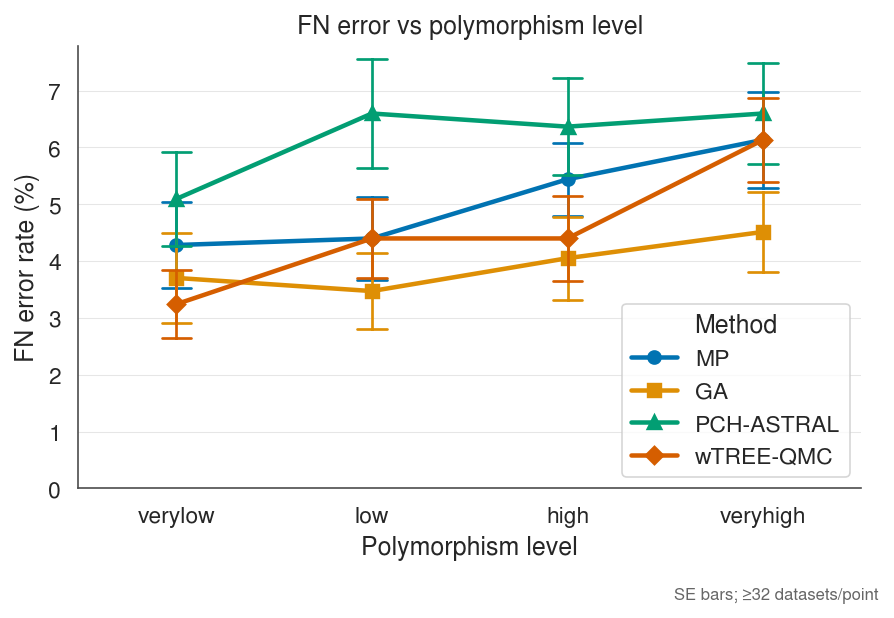

In [5]:
plot_fn("poly_level", "Polymorphism level")

## Homoplasy factor

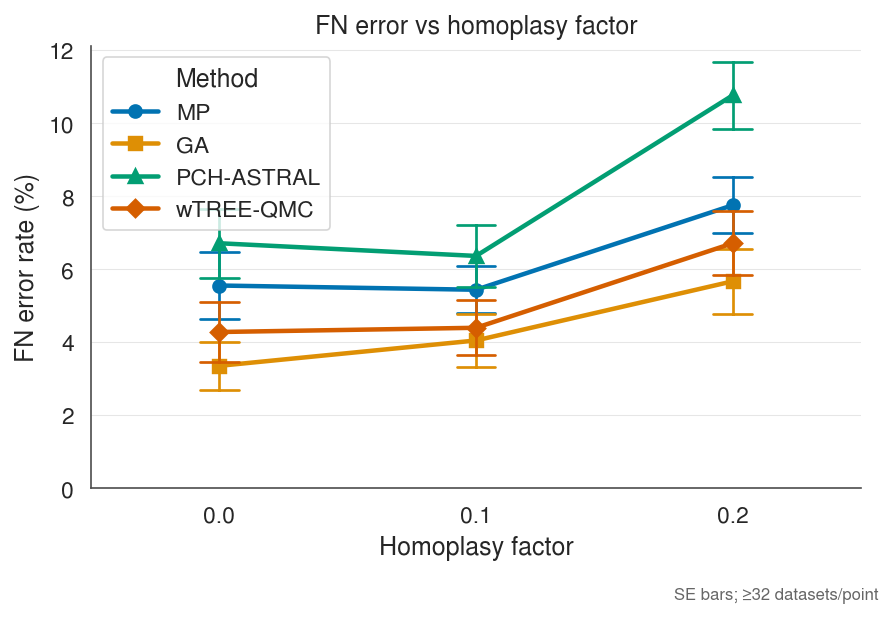

In [6]:
plot_fn("homoplasy_factor", "Homoplasy factor")

## Tree height

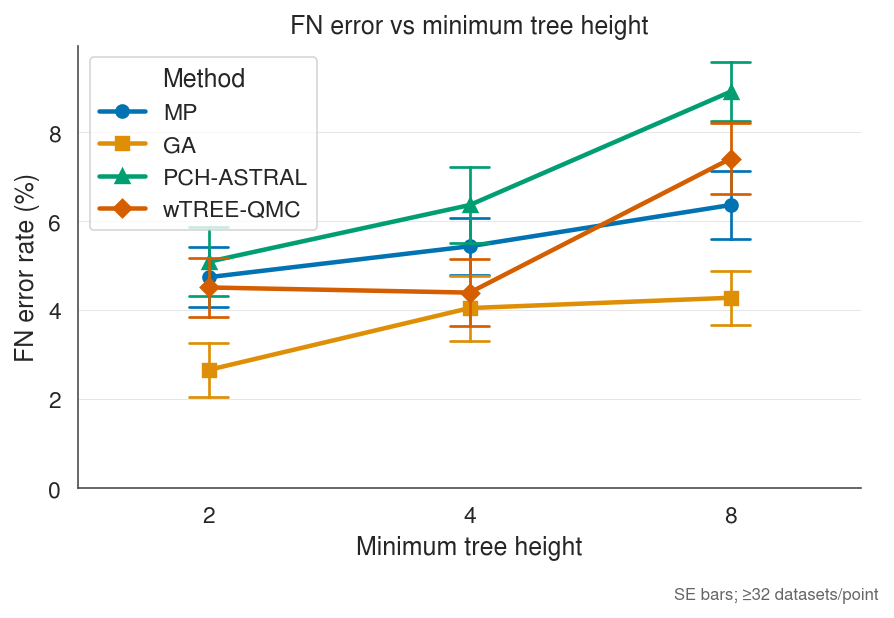

In [7]:
plot_fn("min_tree_height", "Minimum tree height")

## Character count

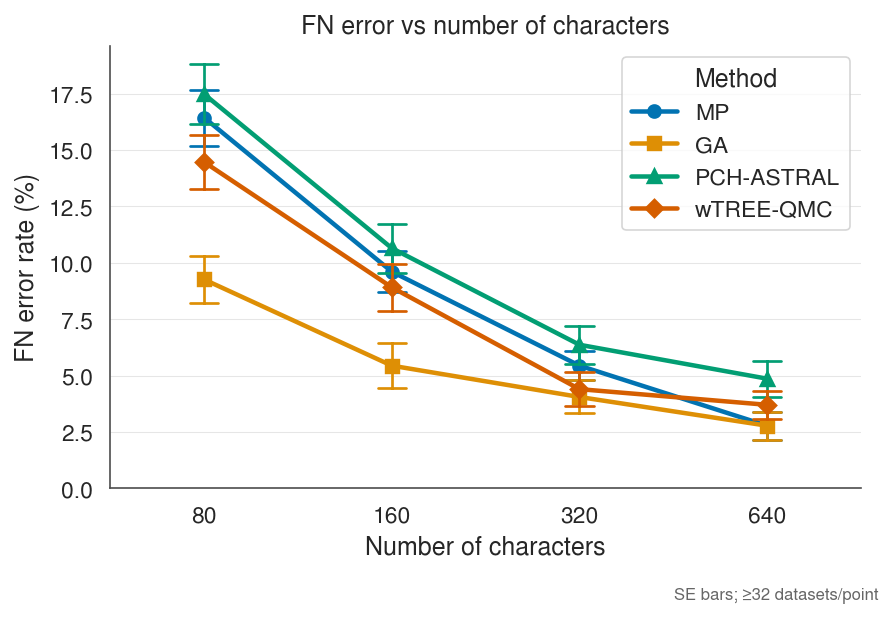

In [8]:
plot_fn("character_count", "Number of characters")

## Runtime vs number of characters

Number of characters is the dominant runtime driver, so we sweep it
(`poly=high, homoplasy=0.1, tree_height=4`; chars 80/320/640) with the other
parameters at default. Log y-axis — ASTRAL's weighted-quartet count grows with `n_chars`.

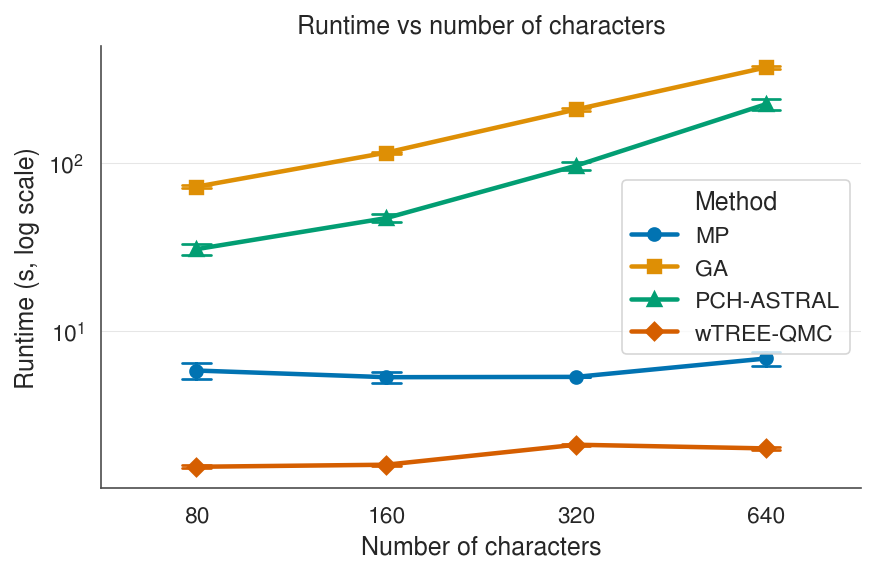

In [9]:
sub = sweep("character_count")
order = order_for("character_count", sub)
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(
    data=sub, x="character_count", y="runtime_seconds", hue="Method",
    order=order, hue_order=METHOD_ORDER, palette=PALETTE,
    errorbar="se", capsize=0.15, err_kws={"linewidth": 1.3},
    dodge=False, linestyle="-", markers=MARKERS, ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Number of characters")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("Runtime vs number of characters")
ax.legend(title="Method")
fig.tight_layout()
for _e in EXTS:
    fig.savefig(FIGS / f"runtime_by_character_count.{_e}")
plt.show()